# Random Forest 

Une Random Forest est une méthode d'apprentissage d'ensemble composée d'une collection de $L$ arbres de décision, où chaque arbre est "randomisé": les arbres sont construits à partir de vecteurs aléatoires $\{\theta_{k}\}$ indépendants et identiquement distribués (i.i.d.). Pour une nouvelle instance $x$, chaque arbre émet un vote pour une classe. La forêt choisit la classe ayant reçu la majorité des votes.

**Il n'y a pas besoin de normaliser les données pour le Random Forest car les arbres se basent sur l’ordre des valeurs, pas sur leur échelle, autrement dit les arbres ne font pas de calcul de distance.**

Bagging (Bootstrap Aggregating): C'est la première source d'aléatoire. Pour chaque arbre $k$ de la forêt: 
- On crée un échantillon Bootstrap : on tire au sort $p$ instances dans le jeu de données initial $D$, avec remplacement.
- Cela signifie qu'un même individu peut être utilisé plusieurs fois pour un arbre, alors que d'autres ne sont pas utilisés du tout (les individus Out-of-Bag, ils sont utiles car ils permettent de tester l'arbre immédiatement car ils ne sont pas utilisés pour l'entraînement).
- On entraîne l'arbre sur ce sous-ensemble spécifique.

Random Subspace: C'est la deuxième source d'aléatoire, cruciale pour la diversité. But: réduire la corrélation entre les arbres pour que, lorsqu'on fait la moyenne, l'erreur globale diminue.
- À chaque nœud de chaque arbre, l'algorithme ne choisit pas la meilleure division parmi toutes les variables.
- Il tire au sort un sous-ensemble de $p$ caractéristiques (souvent $p = \sqrt{d}$) et cherche la meilleure division uniquement parmi celles-ci. Cela évite qu'une variable très dominante ne rende tous les arbres identiques.

Pour classer une nouvelle instance $x$:  
Par classification:
- On fait passer $x$ à travers chacun des $L$ arbres de la forêt.
- Chaque arbre $h_k(x)$ donne son propre vote (une classe $\lambda_i$).
- La forêt prédit la classe qui a obtenu le maximum de votes (vote majoritaire).

On peut aussi classer par régression: moyenne arithmétique des prédictions de tous les arbres.

Paramètres du modèle:
- nombre d'arbres ($L$) : Ajouter des arbres améliore globalement la performance car cela réduit la variance du modèle. Cependant, le gain de précision suit une loi de rendement décroissant : après quelques centaines d'arbres, l'erreur de test atteint un plateau et ne baisse plus. Une random forest ne fait pas d'overfitting en ajoutant des arbres. Contrairement à d'autres modèles où trop d'itérations peuvent nuires, ajouter des arbres ne peut que stabiliser le modèle mais il le temps computationnel augmente !

Le but d'une forêt aléatoire est que les arbres soient le plus différents possible les uns des autres (décorrélation). C'est pour ça qu'on introduit le paramètre p qui empêche les arbres de toujours prendre la meilleure feature du noeud.
- nombre de caractéristiques par nœud ($p$) : Sa valeur optimale dépend du nombre de caractéristiques non pertinentes dans le dataset. Des valeurs populaires sont $1$, $\sqrt{d}$ ou $\log_2(d)$.
paramètres: max_features{“sqrt”, “log2”, None}, int or float, default=”sqrt”
  * $p=1$ => randomisation est maximale: Il tire une seule variable au hasard parmi les $d$ variables disponibles et l'utilise.
  * $p=\sqrt{d}$ => compromis standard: Choix entre plusieurs variables.
  * $p=d$ => Choix total (Bagging pur): les arbres seront trop semblables entre eux: risque d'overfitting.

Avantages: 
- Très robuste aux valeurs aberrantes (outliers)
- Gère bien les données manquante
- Capture les relations non-linéaires
- Fournit une mesure de l'importance des variables

Inconvénients:
- Le modèle peut être très lourd en mémoire (si $L$ est grand)
- Lent à prédire en temps réel par rapport à une régression linéaire
- Complexe quand il y a des centaines d'arbres

- MDI (Mean Decrease Impurity) : Mesure le gain d'impureté cumulé pour chaque variable.
- MDA (Mean Decrease Accuracy) : Mesure la baisse de précision de la forêt lorsqu'on permute aléatoirement les valeurs d'une variable.

# 1 - Spambase classification with Random Forest

Pour commencer, on va s'interesser à nouveau au dataset de mails déjà étudiés pour les autres modèles.

In [216]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [217]:
# chargement du dataset "spambase"
dataspam = np.loadtxt("spambase/spambase.data", delimiter=",")
X = dataspam[:,0:57]
y = dataspam[:,-1]

In [218]:
# séparation des données en données d'entraînement et test
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.2,
                                              train_size=0.8)

In [219]:
vect_depth = np.arange(5, 55, 5)
err_train = np.zeros(len(vect_depth))
err_test = np.zeros(len(vect_depth))

for ind_depth, depth in enumerate(vect_depth):
    # n_jobs=-1: exécution en parallèle des arbres
    clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=depth, n_jobs=-1)
    clf.fit(X_train, Y_train)
    err_train[ind_depth]= 1 - accuracy_score(Y_train, clf.predict(X_train))
    err_test[ind_depth]= 1 - accuracy_score(Y_test, clf.predict(X_test))

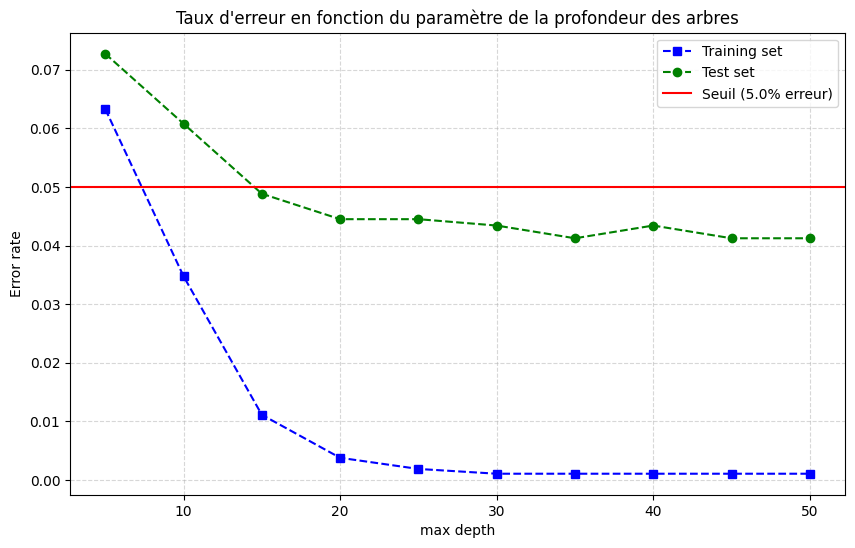

In [220]:
plt.figure(figsize=(10, 6))
plt.plot(vect_depth, err_train, "bs--", label="Training set ")
plt.plot(vect_depth, err_test, "go--", label="Test set ")
plt.title("Taux d'erreur en fonction du paramètre de la profondeur des arbres", fontsize=12)
plt.xlabel("max depth")
plt.ylabel("Error rate")
seuil = 0.05
plt.axhline(y=seuil, color='r', label=f"Seuil ({100*seuil:.1f}% erreur)")
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(loc="best");

In [221]:
ind_min = err_test.argmin()
depthOpt = vect_depth[ind_min]
print(f"\n Optimal depth = {depthOpt}, erreur de {err_test[ind_min]:.4f}")


 Optimal depth = 35, erreur de 0.0413


In [222]:
feature_names = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d", "word_freq_our",
    "word_freq_over", "word_freq_remove", "word_freq_internet", "word_freq_order",
    "word_freq_mail", "word_freq_receive", "word_freq_will", "word_freq_people",
    "word_freq_report", "word_freq_addresses", "word_freq_free", "word_freq_business",
    "word_freq_email", "word_freq_you", "word_freq_credit", "word_freq_your",
    "word_freq_font", "word_freq_000", "word_freq_money", "word_freq_hp",
    "word_freq_hpl", "word_freq_george", "word_freq_650", "word_freq_lab",
    "word_freq_labs", "word_freq_telnet", "word_freq_857", "word_freq_data",
    "word_freq_415", "word_freq_85", "word_freq_technology", "word_freq_1999",
    "word_freq_parts", "word_freq_pm", "word_freq_direct", "word_freq_cs",
    "word_freq_meeting", "word_freq_original", "word_freq_project", "word_freq_re",
    "word_freq_edu", "word_freq_table", "word_freq_conference",
    "char_freq_;", "char_freq_(", "char_freq_[", "char_freq_!", "char_freq_$",
    "char_freq_#", "capital_run_length_average",
    "capital_run_length_longest", "capital_run_length_total"
]

importances = clf.feature_importances_
indices_sorted = np.argsort(importances)[::-1]

In [223]:
print("Features triées par importance :")
for idx in indices_sorted[:10]:
    print(f"{feature_names[idx]:35s}  importance = {importances[idx]:.4f}")

Features triées par importance :
char_freq_!                          importance = 0.1238
char_freq_$                          importance = 0.0981
word_freq_remove                     importance = 0.0746
word_freq_free                       importance = 0.0601
capital_run_length_average           importance = 0.0583
word_freq_your                       importance = 0.0554
capital_run_length_longest           importance = 0.0545
capital_run_length_total             importance = 0.0516
word_freq_hp                         importance = 0.0462
word_freq_you                        importance = 0.0295


In [224]:
err_train = 1 - accuracy_score(Y_train, clf.predict(X_train))
err_test = 1- accuracy_score(Y_test, clf.predict(X_test))
print(f"Erreur de train: {err_train*100:.2f}%")
print(f"Erreur de test: {err_test*100:.2f}%")

Erreur de train: 0.11%
Erreur de test: 4.13%


On constate un très faible taux d'erreur sur les données d'entraînement (<1%), on pourrait donc s'attendre à ce que le modèle sur-apprenne cependant on a également un faible taux d'erreur sur les données de test (<4%).

Comparons ces scores à ceux du modèle SVM:

In [225]:
# on normalise les données pour le SVM car ce modèle est basé sur des calculs de distance.
sc = StandardScaler(with_mean=True, with_std=True)
sc = sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

clfker = SVC(kernel="rbf")
clfker.gamma = 0.1
clfker.C = 10
clfker.fit(X_train, Y_train)
err_train = 1 - accuracy_score(Y_train, clfker.predict(X_train))
err_test = 1- accuracy_score(Y_test, clfker.predict(X_test))
print(f"Erreur de train: {err_train*100:.2f}%")
print(f"Erreur de test: {err_test*100:.2f}%")

Erreur de train: 0.79%
Erreur de test: 9.12%


On constate un taux d'erreur toujours faible pour les données d'entraînement, mais assez proche de 1. Ce qui nous intéresse le plus c'est que les données de test ont perdu casiment 5 points (selon le découpage des données) sur le taux d'erreur.  
On peut conclure que pour ce dataset, le modèle kernel SVM semble moins robuste que le modèle Random Forest.

On va tout de même tester le modèle Random Forest sur des donnés normalisées pour voir la différence:

In [226]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [227]:
err_train = 1 - accuracy_score(Y_train, clf.predict(X_train))
err_test = 1- accuracy_score(Y_test, clf.predict(X_test))
print(f"Erreur de train: {err_train*100:.2f}%")
print(f"Erreur de test: {err_test*100:.2f}%")

Erreur de train: 0.11%
Erreur de test: 4.02%


On constate qu'on obtient sensiblement les mêmes résultats, ce qui confirme le fait qu'il est inutile de normaliser les données pour le Random Forest. C'est logique car le principe même de ce modèle fait qu'il n'y a pas besoin de normaliser les données.

# 2 - Tuning the max_features hyperparameter

Retour sur l'hyperparamètre "max_features", crucial pour la performance du modèle. Ce paramètre contrôle le nombre de features qui sont aléatoirement selectionnées pour séparer chaque noeud de l'arbre de décision.  
La valeur par défaut proposé par scikit-lean est √d, avec d: nombre de features du dataset.  

In [333]:
digit = load_digits()
X = digit.data
y = digit.target
n_instances , n_features = X.shape

In [334]:
print(f"Exemple de feature (ce sont toutes les mêmes):\n {digit.feature_names[0]}")

Exemple de feature (ce sont toutes les mêmes):
 pixel_0_0


Les features de ce dataset sont des pixels. Oui, on peut dire qu’intuitivement toutes les features sont pertinentes, mais certaines le sont beaucoup plus que d’autres, par exemple celles aux centres/ éloignés des bords.

On entraîne le modèle Random Forest selon différentes valeurs de max_features afin de comparer leur performances.

In [335]:
# pour chaque réglage, on répète l'entraînement et la prédiction 10 fois avec des mélanges de données différents
# cela a pour but de lutter contre le hasard du découpage des données
n_replications = 10
vect = np.arange(1,32,1)
# on va tester différentes valeurs de nombre d'arbres pour la forêt
list_features = range(1, n_features +1, 2)
err_train = []
err_test = []
# pour chaque nombre d'arbre dans la forêt 
for k in list_features:
    clf = RandomForestClassifier(n_estimators=k, max_depth=depthOpt)
    # pour le stockage des résultats des 10 prochaines répliques
    # cela permettra d'afficher un seul point moyen pour chaque nombre d'arbres
    # car on pourra faire la moyenne de la sous-liste l_err_train pour depth=3 par exemple, de la liste err_train
    l_err_train = []
    l_err_test = []
    # pour chaque réplique de ce nombre d'arbre
    for i in range(n_replications):
        X_train , X_test , Y_train , Y_test = train_test_split(
            X, y, test_size =0.2)
        clf.fit(X_train, Y_train)
        l_err_train.append(1 - accuracy_score(Y_train, clf.predict(X_train)))
        l_err_test.append(1 - accuracy_score(Y_test, clf.predict(X_test)))
    err_train.append(l_err_train)
    err_test.append(l_err_test)

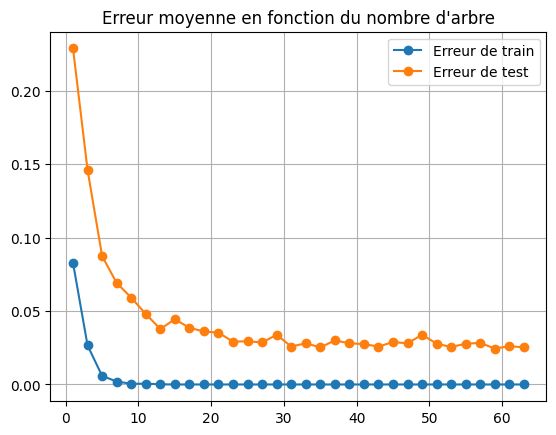

In [336]:
plt.plot(list_features, [np.mean(l) for l in err_train], 'o-', label="Erreur de train")
plt.plot(list_features, [np.mean(l) for l in err_test], 'o-', label="Erreur de test")
plt.legend()
plt.title("Erreur moyenne en fonction du nombre d'arbre")
plt.grid()
plt.show()

La Moyenne = La Précision : Indique si le modèle est performant.

- Convergence rapide : On observe une chute drastique de l'erreur de test entre 1 et 10 arbres. Cela confirme ta théorie : l'agrégation d'arbres réduit rapidement la variance globale du modèle.
- Plateau de performance : Au-delà de 20-25 arbres, le gain de précision devient marginal (loi des rendements décroissants). L'erreur de test se stabilise autour de 2,5% - 3%.
- Surapprentissage maîtrisé : Bien que l'erreur de train tombe à 0 très vite, l'erreur de test ne remonte pas, ce qui prouve que l'ajout d'arbres ne provoque pas de surapprentissage.

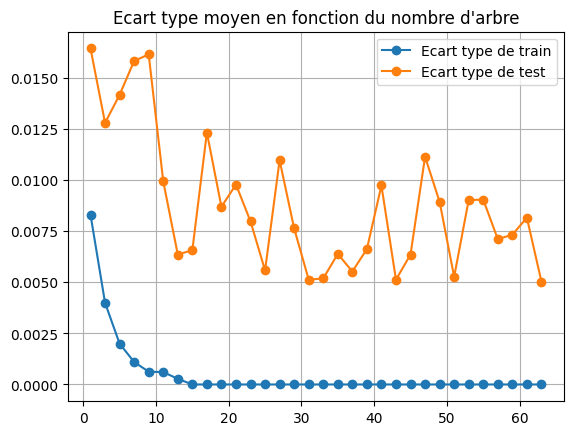

In [337]:
plt.plot(list_features, [np.std(l) for l in err_train], 'o-', label="Ecart type de train")
plt.plot(list_features, [np.std(l) for l in err_test], 'o-', label="Ecart type de test")
plt.legend()
plt.title("Ecart type moyen en fonction du nombre d'arbre")
plt.grid()
plt.show()

L'Écart-type=  La Fiabilité (Stabilité) : Indique si on peut avoir confiance dans ce score de précision.

- Réduction de l'instabilité : L'écart-type de l'erreur de test diminue globalement à mesure que le nombre d'arbres augmente.
- Le "bruit" résiduel : L'écart-type ne tombe jamais à zéro (contrairement au train), ce qui est normal car il restera toujours une part d'aléa liée au choix des données de tes

# 3 - Measuring the importance of features 

On s'intéresse désormais à l'importance du nombre de features du jeu de données. Pour rappel, l'importance d'une feature calculée comme la diminution moyenne des impuretés (ex: impureté de Gini).  
On se base donc sur cette impureté pour évaluer la performance d'une feature dans l'optique futur de faire une sélection de features.

In [352]:
X, y = make_classification(n_samples =1000 , n_features =20, 
                           n_informative =5, n_redundant =0)

In [353]:
print(f"nombre de features du dataset: {y.shape[0]}")

nombre de features du dataset: 1000


On entraîne un Random Forest sur l'ensemble des features 

In [354]:
clf = RandomForestClassifier(n_estimators=200)
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.2,
                                              train_size=0.8)
clf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [355]:
err_train = 1 - accuracy_score(Y_train, clf.predict(X_train))
err_test = 1- accuracy_score(Y_test, clf.predict(X_test))
print(f"Erreur de train: {err_train*100:.2f}%")
print(f"Erreur de test: {err_test*100:.2f}%")

Erreur de train: 0.00%
Erreur de test: 14.50%


In [356]:
# tableau: récupère le score d'importance de chaque variable, probablement via MDI
importances = clf.feature_importances_

In [357]:
# liste d'indices des features du plus au moins important
indices_sorted = np.argsort(importances)[::-1] 
print(indices_sorted)

# 10 meilleures variables
top_k = 10 
# indices des 10 variables les plus importantes
top_features = indices_sorted[:top_k]
# scores des 10 variables les plus importantes
top_importances = importances[top_features]

print(f"Ranking of features by importance")
for idx, imp in zip(top_features, top_importances):
    print(f"Feature {idx} — importance = {imp:.4f}")

[ 8  3 13 16 17 15  6  2  7 10 18  1  4 12 11  0  5 19  9 14]
Ranking of features by importance
Feature 8 — importance = 0.1615
Feature 3 — importance = 0.1399
Feature 13 — importance = 0.1214
Feature 16 — importance = 0.1014
Feature 17 — importance = 0.0909
Feature 15 — importance = 0.0289
Feature 6 — importance = 0.0277
Feature 2 — importance = 0.0268
Feature 7 — importance = 0.0266
Feature 10 — importance = 0.0262


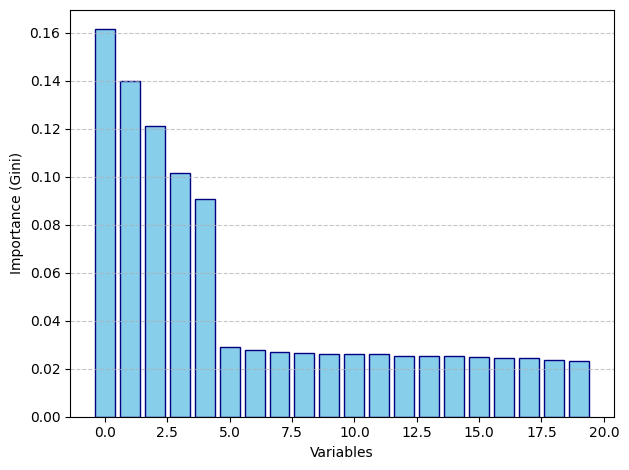

In [358]:
# range(X.shape[1]): créé 20 emplacements vides sur l'axe x pour les 20 barres (il y a 20 features)
# importances[indices_sorted]: affiche les features de la plus à la moins importante
plt.bar(range(X.shape[1]), importances[indices_sorted], align="center", color='skyblue', edgecolor='navy')
plt.xlabel("Variables")
plt.ylabel("Importance (Gini)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Les 5 premières barres du barplot correspondant aux 5 informative features: ce sont les features qui vont prendre les décisions car elles ont l'impureté de Gini la plus grande. On visualise bien ici le paramètre "n_informative =5".